In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OrdinalEncoder

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA

def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [2]:
df = pd.read_csv('ai_job_market.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   job_id            2000 non-null   int64 
 1   company_name      2000 non-null   object
 2   industry          2000 non-null   object
 3   job_title         2000 non-null   object
 4   skills_required   2000 non-null   object
 5   experience_level  2000 non-null   object
 6   employment_type   2000 non-null   object
 7   location          2000 non-null   object
 8   salary_range_usd  2000 non-null   object
 9   posted_date       2000 non-null   object
 10  company_size      2000 non-null   object
 11  tools_preferred   2000 non-null   object
dtypes: int64(1), object(11)
memory usage: 187.6+ KB


In [3]:
df.head()

,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred
0,1,Foster and Sons,Healthcare,Data Analyst,"NumPy, Reinforcement Learning, PyTorch, Scikit...",Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,Large,"KDB+, LangChain"
1,2,"Boyd, Myers and Ramirez",Tech,Computer Vision Engineer,"Scikit-learn, CUDA, SQL, Pandas",Senior,Full-time,"Lake Scott, CU",78523-144875,2024-03-22,Large,"FastAPI, KDB+, TensorFlow"
2,3,King Inc,Tech,Quant Researcher,"MLflow, FastAPI, Azure, PyTorch, SQL, GCP",Entry,Full-time,"East Paige, CM",124496-217204,2025-09-18,Large,"BigQuery, PyTorch, Scikit-learn"
3,4,"Cooper, Archer and Lynch",Tech,AI Product Manager,"Scikit-learn, C++, Pandas, LangChain, AWS, R",Mid,Full-time,"Perezview, FI",50908-123743,2024-05-08,Large,"TensorFlow, BigQuery, MLflow"
4,5,Hall LLC,Finance,Data Scientist,"Excel, Keras, SQL, Hugging Face",Senior,Contract,"North Desireeland, NE",98694-135413,2025-02-24,Large,"PyTorch, LangChain"


In [4]:
df.tail()

,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred
1995,1996,"Mueller, Ellis and Clark",Finance,NLP Engineer,"Flask, FastAPI, Power BI",Senior,Internship,"Washingtonmouth, SD",90382-110126,2024-04-22,Large,MLflow
1996,1997,Roberts-Yu,Automotive,AI Product Manager,"R, Flask, Excel, C++, CUDA, Scikit-learn",Mid,Remote,"Joshuafort, ZA",47848-137195,2023-12-02,Large,"KDB+, LangChain, MLflow"
1997,1998,"Brooks, Williams and Randolph",Education,Data Analyst,"Hugging Face, Excel, Scikit-learn, R, MLflow",Entry,Contract,"West Brittanyburgh, CG",134994-180108,2023-10-29,Large,PyTorch
1998,1999,Castaneda-Smith,Education,Quant Researcher,"AWS, Python, Scikit-learn",Senior,Contract,"Anthonyshire, OM",62388-82539,2024-08-10,Large,"MLflow, TensorFlow, FastAPI"
1999,2000,Estes Group,Finance,Quant Researcher,"Flask, TensorFlow, Power BI",Senior,Full-time,"Benjaminview, NE",55835-97374,2025-02-20,Startup,MLflow


In [5]:
df.job_id.nunique()

2000

In [6]:
df2 = df.drop('job_id', axis = 1)

In [7]:
df2.describe()

,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred
count,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000
unique,1909,7,8,1985,3,4,2000,2000,680,3,352
top,Johnson LLC,Automotive,Data Analyst,"Power BI, C++, NumPy",Entry,Internship,"Tracybury, AR",92860-109598,2023-10-03,Startup,KDB+
freq,4,300,271,2,702,574,1,1,10,672,96


In [8]:
df2['company_name'].unique()

array(['Foster and Sons', 'Boyd, Myers and Ramirez', 'King Inc', ...,
       'Brooks, Williams and Randolph', 'Castaneda-Smith', 'Estes Group'],
      dtype=object)

In [9]:
df2['company_name'].value_counts()

company_name
Johnson LLC                  4
Smith Inc                    3
Taylor PLC                   3
Anderson PLC                 3
Martin and Sons              3
                            ..
Robinson PLC                 1
Lyons Inc                    1
Jones, Spencer and Bowers    1
Clayton, Pratt and Stone     1
Estes Group                  1
Name: count, Length: 1909, dtype: int64

In [10]:
df2['industry'].value_counts().head(20)

industry
Automotive    300
Education     294
Retail        293
E-commerce    291
Finance       279
Tech          274
Healthcare    269
Name: count, dtype: int64

In [11]:
df['job_title'].value_counts().head(20)

job_title
Data Analyst                271
NLP Engineer                265
AI Product Manager          258
Quant Researcher            251
ML Engineer                 250
Data Scientist              238
AI Researcher               237
Computer Vision Engineer    230
Name: count, dtype: int64

In [12]:
df['posted_date'].min(), df['posted_date'].max()

('2023-09-21', '2025-09-19')

In [13]:
df['salary_range_usd'].head()

0     92860-109598
1     78523-144875
2    124496-217204
3     50908-123743
4     98694-135413
Name: salary_range_usd, dtype: object

In [14]:
def calcAve(x):
    a, b = x.split('-')
    return (int(a)+int(b)) // 2
df2['mean_salary'] = df2['salary_range_usd'].apply(calcAve)

In [15]:
temp=df2.groupby('posted_date').agg({'mean_salary': ['mean']})
temp

,mean_salary
,mean
posted_date,
2023-09-21,156002.000000
2023-09-22,114271.000000
2023-09-23,68486.333333
2023-09-24,81971.500000
2023-09-25,101460.000000
...,...
2025-09-15,134246.500000
2025-09-16,129278.333333


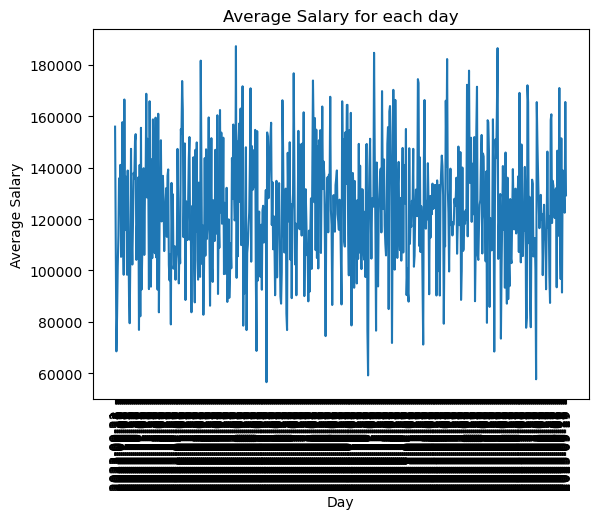

In [16]:
plt.plot(temp.index, temp['mean_salary'])
plt.xticks(rotation=90)
plt.title('Average Salary for each day')
plt.xlabel('Day')
plt.ylabel('Average Salary')
plt.show()

In [17]:
def fetchYearMonth(x):
    return x[:7]

df2['posted_year_month'] = df2['posted_date'].apply(fetchYearMonth)

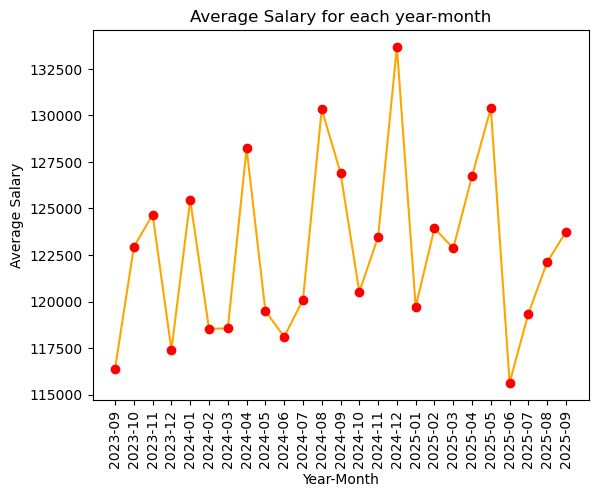

In [18]:
temp = df2.groupby('posted_year_month').agg({'mean_salary': 'mean'})

plt.plot(temp.index, temp['mean_salary'], color='orange', marker='o',
         markerfacecolor='red', markeredgecolor='red')

plt.xticks(rotation=90)
plt.title('Average Salary for each year-month')
plt.xlabel('Year-Month')
plt.ylabel('Average Salary')
plt.show()


In [19]:
temp = df2.groupby('job_title').agg({'mean_salary': 'mean'})
temp.sort_values('mean_salary', ascending=False)

,mean_salary
job_title,
NLP Engineer,125307.332075
Data Analyst,125101.147601
ML Engineer,123953.380000
Data Scientist,123449.050420
AI Researcher,123230.303797
Computer Vision Engineer,122880.886957
Quant Researcher,120505.059761
AI Product Manager,119715.027132


In [20]:
temp = df2.groupby('industry').agg({'mean_salary': 'mean'})
temp.sort_values('mean_salary', ascending=False)

,mean_salary
industry,
E-commerce,124745.044674
Automotive,124545.756667
Tech,123217.182482
Finance,123040.215054
Retail,122791.051195
Education,121796.425170
Healthcare,120964.000000


In [21]:
temp = df2.groupby(['industry', 'job_title']).agg({'mean_salary': 'mean'})
temp.sort_values('mean_salary', ascending=False)

,,mean_salary
industry,job_title,
Retail,Data Analyst,132805.823529
E-commerce,ML Engineer,131550.837838
Education,Data Scientist,130636.263158
E-commerce,NLP Engineer,129963.414634
Automotive,NLP Engineer,129428.325000
Healthcare,AI Researcher,129288.388889
Tech,NLP Engineer,129188.941176
Automotive,Data Analyst,129048.510204
Tech,AI Researcher,128598.862069


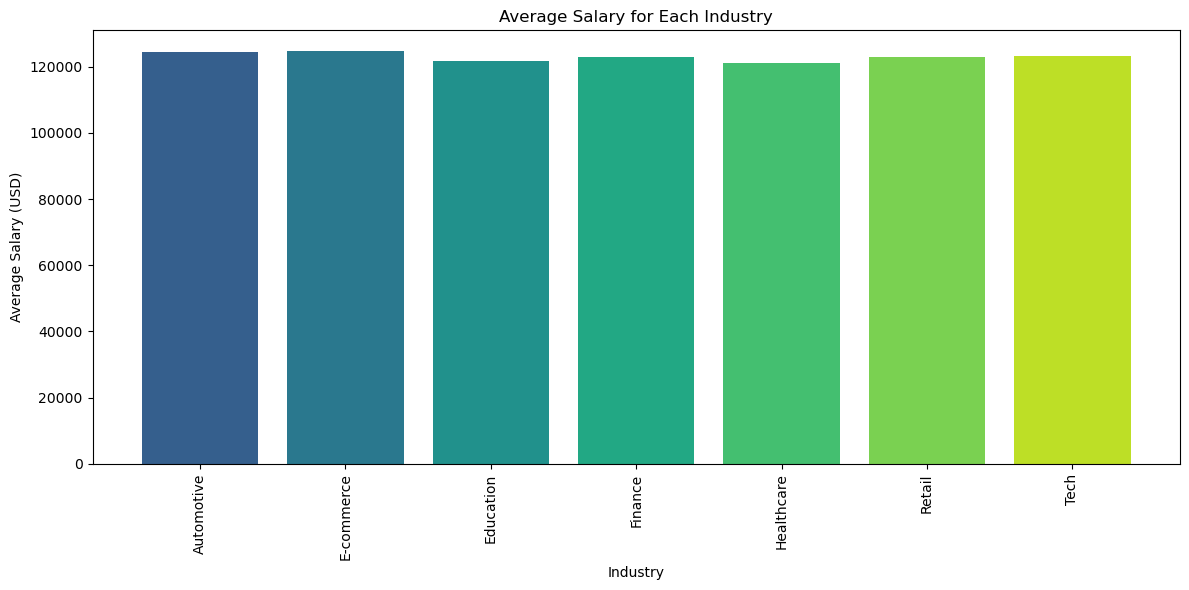

In [22]:
temp = df2.groupby('industry').agg({'mean_salary': 'mean'})
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(temp)))

plt.figure(figsize=(12,6))
plt.bar(temp.index, temp['mean_salary'], color=colors)
plt.xticks(rotation=90)
plt.title('Average Salary for Each Industry')
plt.xlabel('Industry')
plt.ylabel('Average Salary (USD)')
plt.tight_layout()
plt.show()

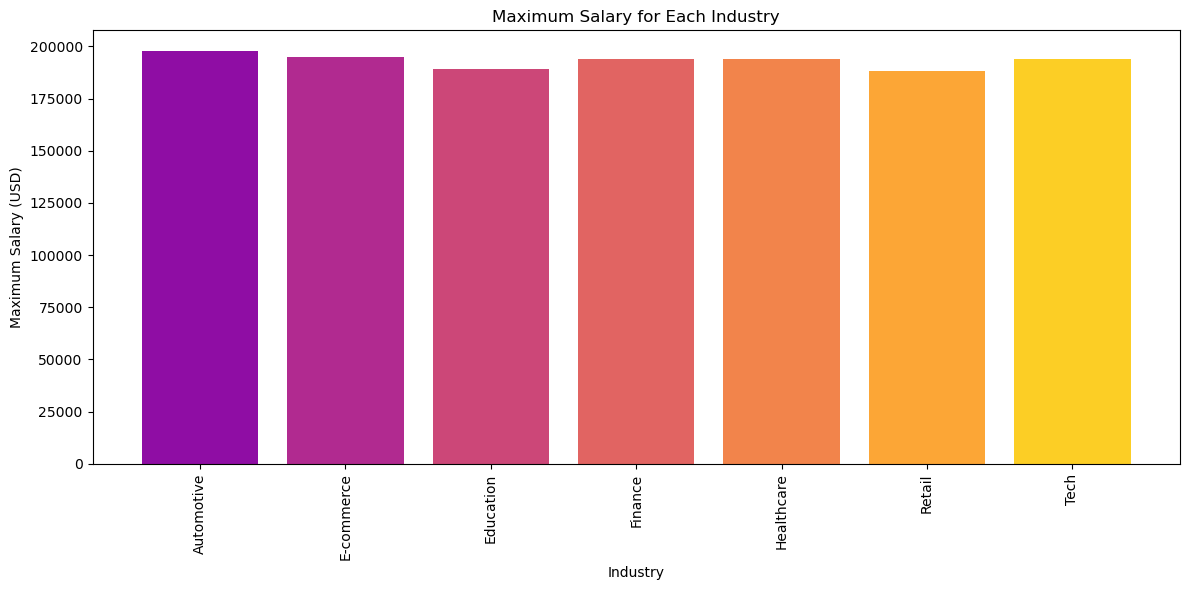

In [23]:
temp = df2.groupby('industry').agg({'mean_salary': 'max'})
colors = plt.cm.plasma(np.linspace(0.3, 0.9, len(temp)))

plt.figure(figsize=(12,6))
plt.bar(temp.index, temp['mean_salary'], color=colors)
plt.xticks(rotation=90)
plt.title('Maximum Salary for Each Industry')
plt.xlabel('Industry')
plt.ylabel('Maximum Salary (USD)')
plt.tight_layout()
plt.show()

In [24]:
temp = df2.groupby('industry').agg({'mean_salary': ['min', 'mean', 'max']})
temp

mean_salary                       
                   min           mean     max
industry                                     
Automotive       49431  124545.756667  197776
E-commerce       55611  124745.044674  194743
Education        50712  121796.425170  189067
Finance          54206  123040.215054  193918
Healthcare       49666  120964.000000  194145
Retail           47578  122791.051195  188355
Tech             53651  123217.182482  193761

In [25]:
industries = df.industry.value_counts()
industries

industry
Automotive    300
Education     294
Retail        293
E-commerce    291
Finance       279
Tech          274
Healthcare    269
Name: count, dtype: int64

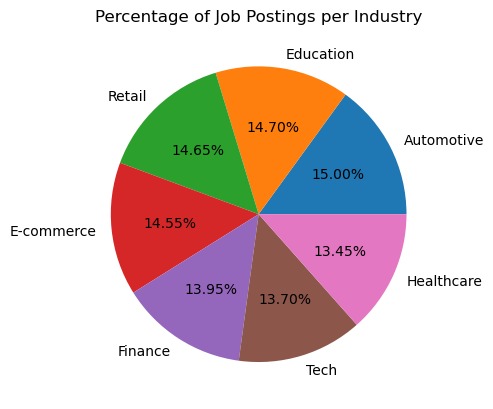

In [26]:
plt.pie(industries.values,labels=industries.index, autopct='%0.2f%%')
plt.title('Percentage of Job Postings per Industry')
plt.show()

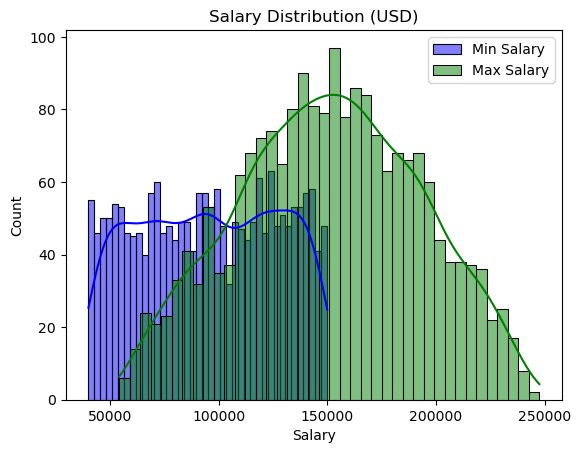

In [27]:
df2[['min_salary','max_salary']] = df2['salary_range_usd'].str.split('-', expand=True).astype(int)
sns.histplot(df2['min_salary'], bins=40, kde=True, color="blue", label="Min Salary")
sns.histplot(df2['max_salary'], bins=40, kde=True, color="green", label="Max Salary")
plt.title("Salary Distribution (USD)")
plt.xlabel("Salary")
plt.legend()
plt.show()

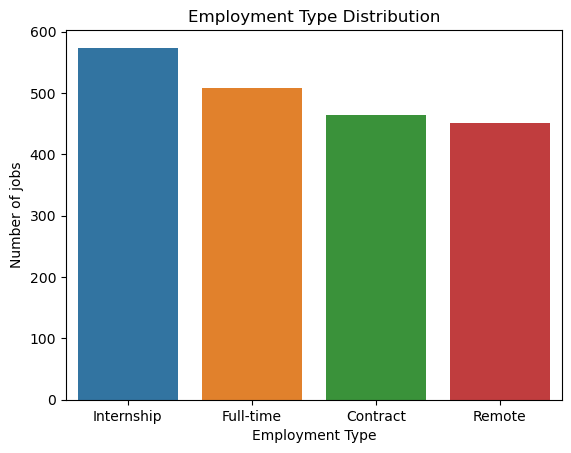

In [28]:
remote_jobs = df2["employment_type"].value_counts()
sns.barplot(x=remote_jobs.index, y=remote_jobs.values)
plt.title("Employment Type Distribution")
plt.xlabel("Employment Type")
plt.ylabel("Number of jobs")
plt.show()

In [29]:
df.location.nunique()

2000

In [30]:
df2 = df2.drop(['company_name', 'location'], axis = 1)

In [31]:
df2.posted_date = pd.to_datetime(df2.posted_date)

In [32]:
df2.posted_date.min(), df2.posted_date.max()

(Timestamp('2023-09-21 00:00:00'), Timestamp('2025-09-19 00:00:00'))

In [33]:
skills = set()
for row in df2['skills_required'].apply(lambda x: x.split(',')):
    for item in row:
        skills.add(item.strip())
print(skills)

{'GCP', 'MLflow', 'TensorFlow', 'SQL', 'PyTorch', 'Keras', 'LangChain', 'R', 'Hugging Face', 'C++', 'AWS', 'NumPy', 'Power BI', 'CUDA', 'Pandas', 'FastAPI', 'Azure', 'Python', 'Scikit-learn', 'Reinforcement Learning', 'Flask', 'Excel'}


In [34]:
df_skills = pd.DataFrame(columns=list(skills))
df_skills

,GCP,MLflow,TensorFlow,SQL,PyTorch,Keras,LangChain,R,Hugging Face,C++,...,Power BI,CUDA,Pandas,FastAPI,Azure,Python,Scikit-learn,Reinforcement Learning,Flask,Excel


In [35]:
df3 = pd.concat([df2, df_skills], axis = 1).fillna(False)
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   industry                2000 non-null   object        
 1   job_title               2000 non-null   object        
 2   skills_required         2000 non-null   object        
 3   experience_level        2000 non-null   object        
 4   employment_type         2000 non-null   object        
 5   salary_range_usd        2000 non-null   object        
 6   posted_date             2000 non-null   datetime64[ns]
 7   company_size            2000 non-null   object        
 8   tools_preferred         2000 non-null   object        
 9   mean_salary             2000 non-null   int64         
 10  posted_year_month       2000 non-null   object        
 11  min_salary              2000 non-null   int64         
 12  max_salary              2000 non-null   int64   

In [36]:
for i in range(len(df3)):
    items = df3.loc[i]['skills_required'].split(',')
    for item in items:
        df3.loc[i, item.strip()] = True

In [37]:
df4 = df3.drop(['skills_required', 'min_salary', 'max_salary', 'salary_range_usd', 'posted_date', 'tools_preferred', 'posted_year_month'], axis=1)
df4.shape

(2000, 28)

In [38]:
for col in df4.columns:
    print(df4[col].value_counts())
    print('-----')

industry
Automotive    300
Education     294
Retail        293
E-commerce    291
Finance       279
Tech          274
Healthcare    269
Name: count, dtype: int64
-----
job_title
Data Analyst                271
NLP Engineer                265
AI Product Manager          258
Quant Researcher            251
ML Engineer                 250
Data Scientist              238
AI Researcher               237
Computer Vision Engineer    230
Name: count, dtype: int64
-----
experience_level
Entry     702
Mid       668
Senior    630
Name: count, dtype: int64
-----
employment_type
Internship    574
Full-time     509
Contract      465
Remote        452
Name: count, dtype: int64
-----
company_size
Startup    672
Mid        671
Large      657
Name: count, dtype: int64
-----
mean_salary
164119    2
132648    2
77274     2
172099    2
107572    2
         ..
132588    1
131496    1
104723    1
120895    1
76604     1
Name: count, Length: 1985, dtype: int64
-----
GCP
False    1596
True      404
Name: count,

In [39]:
df4.select_dtypes('bool').corr().iloc[0]

GCP                       1.000000
MLflow                   -0.049013
TensorFlow               -0.036637
SQL                      -0.050733
PyTorch                   0.003104
Keras                    -0.006229
LangChain                -0.077768
R                        -0.051356
Hugging Face             -0.038371
C++                      -0.018168
AWS                      -0.008090
NumPy                    -0.027713
Power BI                 -0.045311
CUDA                     -0.006850
Pandas                   -0.064593
FastAPI                  -0.026434
Azure                    -0.028999
Python                   -0.003742
Scikit-learn             -0.042965
Reinforcement Learning   -0.057258
Flask                    -0.026189
Excel                    -0.028035
Name: GCP, dtype: float64

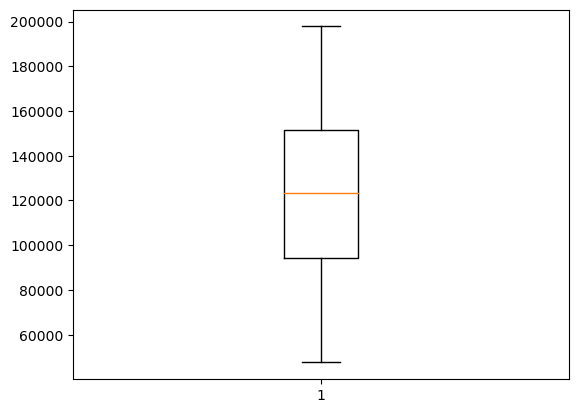

In [40]:
plt.boxplot(df4['mean_salary'])
plt.show()

In [41]:
df5 = pd.get_dummies(df4, drop_first=True)
df5.columns

Index(['mean_salary', 'GCP', 'MLflow', 'TensorFlow', 'SQL', 'PyTorch', 'Keras',
       'LangChain', 'R', 'Hugging Face', 'C++', 'AWS', 'NumPy', 'Power BI',
       'CUDA', 'Pandas', 'FastAPI', 'Azure', 'Python', 'Scikit-learn',
       'Reinforcement Learning', 'Flask', 'Excel', 'industry_E-commerce',
       'industry_Education', 'industry_Finance', 'industry_Healthcare',
       'industry_Retail', 'industry_Tech', 'job_title_AI Researcher',
       'job_title_Computer Vision Engineer', 'job_title_Data Analyst',
       'job_title_Data Scientist', 'job_title_ML Engineer',
       'job_title_NLP Engineer', 'job_title_Quant Researcher',
       'experience_level_Mid', 'experience_level_Senior',
       'employment_type_Full-time', 'employment_type_Internship',
       'employment_type_Remote', 'company_size_Mid', 'company_size_Startup'],
      dtype='object')

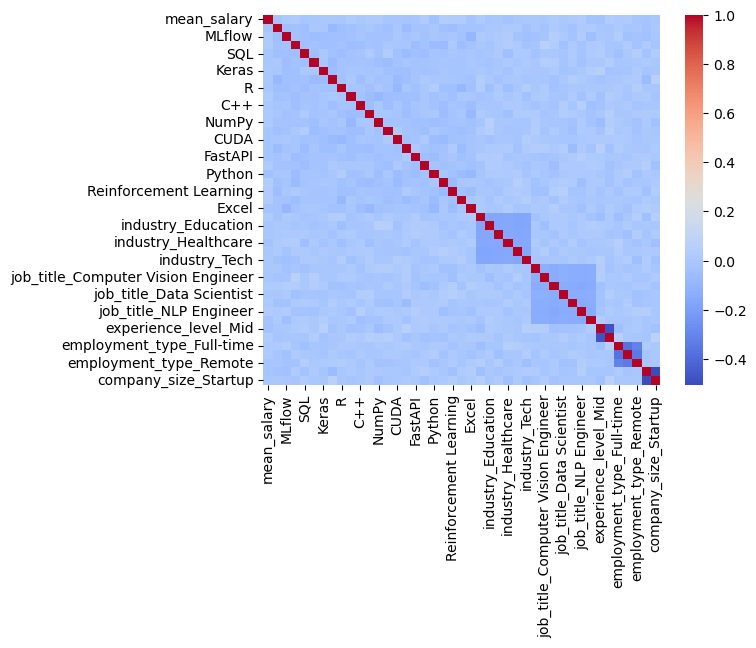

In [42]:
sns.heatmap(df5.corr(), cmap='coolwarm')
plt.show()